# Album Genre Prediction Using Descriptors

This project investigates whether album descriptors can be used to predict an album’s genre using supervised machine learning models.

## Dataset Overview

The dataset contains album genres and descriptors. Each row represents an album, where the first column is the genre and the remaining columns are descriptor words.

The goal is to use these descriptors to predict the genre.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import csv
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")   # prevents popup window
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

In [2]:
INPUT_FILE = "mark_data.csv"
MIN_GENRE_COUNT = 5
TOP_N_GENRES_IN_CM = 15
TOP_N_DESCRIPTOR_IMPORTANCE = 25
RANDOM_STATE = 42

In [3]:
def load_dataset(filepath: str) -> pd.DataFrame:
    rows = []

    with open(filepath, "r", encoding="utf-8", newline="") as f:
        reader = csv.reader(f)
        for row in reader:
            if not row:
                continue

            row = [cell.strip() for cell in row]

            if not any(cell != "" for cell in row):
                continue

            rows.append(row)

    if not rows:
        raise ValueError("The input file is empty or unreadable.")

    max_len = max(len(row) for row in rows)
    padded_rows = [row + [""] * (max_len - len(row)) for row in rows]

    df = pd.DataFrame(padded_rows)

    if df.shape[1] < 2:
        raise ValueError("The file must have at least 2 columns: Genre and at least one descriptor.")

    df = df.rename(columns={0: "Genre"})
    descriptor_cols = [c for c in df.columns if c != "Genre"]

    df["Genre"] = df["Genre"].fillna("").astype(str).str.strip()

    for col in descriptor_cols:
        df[col] = df[col].fillna("").astype(str).str.strip().str.lower()

    df["Descriptors"] = df[descriptor_cols].apply(
        lambda row: " ".join(token for token in row if token != ""),
        axis=1,
    )

    df = df[["Genre", "Descriptors"]].copy()
    df = df[(df["Genre"] != "") & (df["Descriptors"] != "")].copy()

    def dedupe_tokens(text: str) -> str:
        seen = set()
        ordered = []
        for tok in text.split():
            if tok not in seen:
                seen.add(tok)
                ordered.append(tok)
        return " ".join(ordered)

    df["Descriptors"] = df["Descriptors"].apply(dedupe_tokens)

    return df.reset_index(drop=True)

In [4]:
def filter_rare_genres(df: pd.DataFrame, min_count: int) -> pd.DataFrame:
    genre_counts = df["Genre"].value_counts()
    keep_genres = genre_counts[genre_counts >= min_count].index
    filtered = df[df["Genre"].isin(keep_genres)].copy()
    return filtered.reset_index(drop=True)

In [5]:
def build_feature_matrix(df: pd.DataFrame):
    vectorizer = CountVectorizer(binary=True)
    X_desc = vectorizer.fit_transform(df["Descriptors"])
    return X_desc, vectorizer

In [6]:
def evaluate_model(name, model, X_test, y_test, label_encoder):
    preds = model.predict(X_test)

    acc = accuracy_score(y_test, preds)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_test, preds, average="weighted", zero_division=0
    )

    print(f"\n=== {name} ===")
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1-score:  {f1:.4f}")
    print("\nClassification Report:")
    print(
        classification_report(
            y_test,
            preds,
            target_names=label_encoder.classes_,
            zero_division=0,
        )
    )

    return {
        "Model": name,
        "Accuracy": acc,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "Predictions": preds,
    }

In [7]:
def save_confusion_matrix(y_test, preds, label_encoder, output_path, top_n=15):
    y_test_series = pd.Series(y_test)
    top_class_ids = y_test_series.value_counts().head(top_n).index.tolist()

    mask = np.isin(y_test, top_class_ids)
    y_test_top = y_test[mask]
    preds_top = preds[mask]

    labels = sorted(top_class_ids)
    cm = confusion_matrix(y_test_top, preds_top, labels=labels)

    class_names = [label_encoder.inverse_transform([i])[0] for i in labels]

    plt.figure(figsize=(12, 10))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names,
    )
    plt.title("Confusion Matrix (Top Genres)")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.xticks(rotation=45, ha="right")
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.savefig(output_path, dpi=300)
    plt.close()

In [8]:
def save_genre_distribution(df, output_path):
    genre_counts = df["Genre"].value_counts().head(20)

    plt.figure(figsize=(12, 7))
    plt.bar(genre_counts.index, genre_counts.values)
    plt.title("Top 20 Genre Counts")
    plt.xlabel("Genre")
    plt.ylabel("Count")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.savefig(output_path, dpi=300)
    plt.close()

In [9]:
def save_logistic_descriptor_importance(model, vectorizer, output_path, top_n=25):
    if not hasattr(model, "coef_"):
        return

    feature_names = np.array(vectorizer.get_feature_names_out())
    coefs = np.abs(model.coef_)
    avg_importance = coefs.mean(axis=0)

    importance_df = pd.DataFrame({
        "Descriptor": feature_names,
        "Importance": avg_importance
    }).sort_values("Importance", ascending=False)

    importance_df.to_csv(output_path, index=False)

    top_df = importance_df.head(top_n)

    plt.figure(figsize=(10, 8))
    plt.barh(top_df["Descriptor"][::-1], top_df["Importance"][::-1])
    plt.title("Top Descriptor Importance (Logistic Regression)")
    plt.xlabel("Average Absolute Coefficient")
    plt.tight_layout()
    plt.savefig("top_descriptor_importance.png", dpi=300)
    plt.close()

## Loading and Inspecting the Dataset

We first load the dataset and inspect its size and the number of unique genre labels.

In [10]:
df = load_dataset(INPUT_FILE)
print("Initial rows:", len(df))
print("Initial unique genres:", df["Genre"].nunique())
df.head()

Initial rows: 381
Initial unique genres: 134


,Genre,Descriptors
0,Genre,descriptors
1,Abstract Hip Hop,food sampling concept album playful humorous a...
2,Abstract Hip Hop,lo-fi introspective sampling abstract death de...
3,Abstract Hip Hop,ominous sampling futuristic nocturnal humorous...
4,Abstract Hip Hop,sampling playful abstract humorous cryptic mys...


In [11]:
df["Genre"].value_counts().head(20)

Genre
Singer-Songwriter       17
Art Rock                13
Pop Rock                13
Post-Rock               11
Art Pop                 10
Conscious Hip Hop       10
Indie Rock              10
Progressive Rock         9
Alternative Rock         7
Heavy Metal              7
Pop Rap                  7
Experimental Hip Hop     6
Folk Rock                6
Hip Hop                  6
New Wave                 6
Thrash Metal             6
Contemporary R&B         5
Dream Pop                5
Hardcore Hip Hop         5
Abstract Hip Hop         4
Name: count, dtype: int64

## Preprocessing

To make the classification problem more stable, we remove genres with very few samples. This reduces class sparsity and makes the train/test split more meaningful.

In [12]:
df_filtered = filter_rare_genres(df, MIN_GENRE_COUNT)

print("Rows after filtering:", len(df_filtered))
print("Remaining unique genres:", df_filtered["Genre"].nunique())

df_filtered["Genre"].value_counts()

Rows after filtering: 159
Remaining unique genres: 19


Genre
Singer-Songwriter       17
Art Rock                13
Pop Rock                13
Post-Rock               11
Art Pop                 10
Conscious Hip Hop       10
Indie Rock              10
Progressive Rock         9
Alternative Rock         7
Heavy Metal              7
Pop Rap                  7
Experimental Hip Hop     6
Folk Rock                6
Hip Hop                  6
New Wave                 6
Thrash Metal             6
Contemporary R&B         5
Dream Pop                5
Hardcore Hip Hop         5
Name: count, dtype: int64

In [13]:
save_genre_distribution(df_filtered, "top_genres_distribution.png")

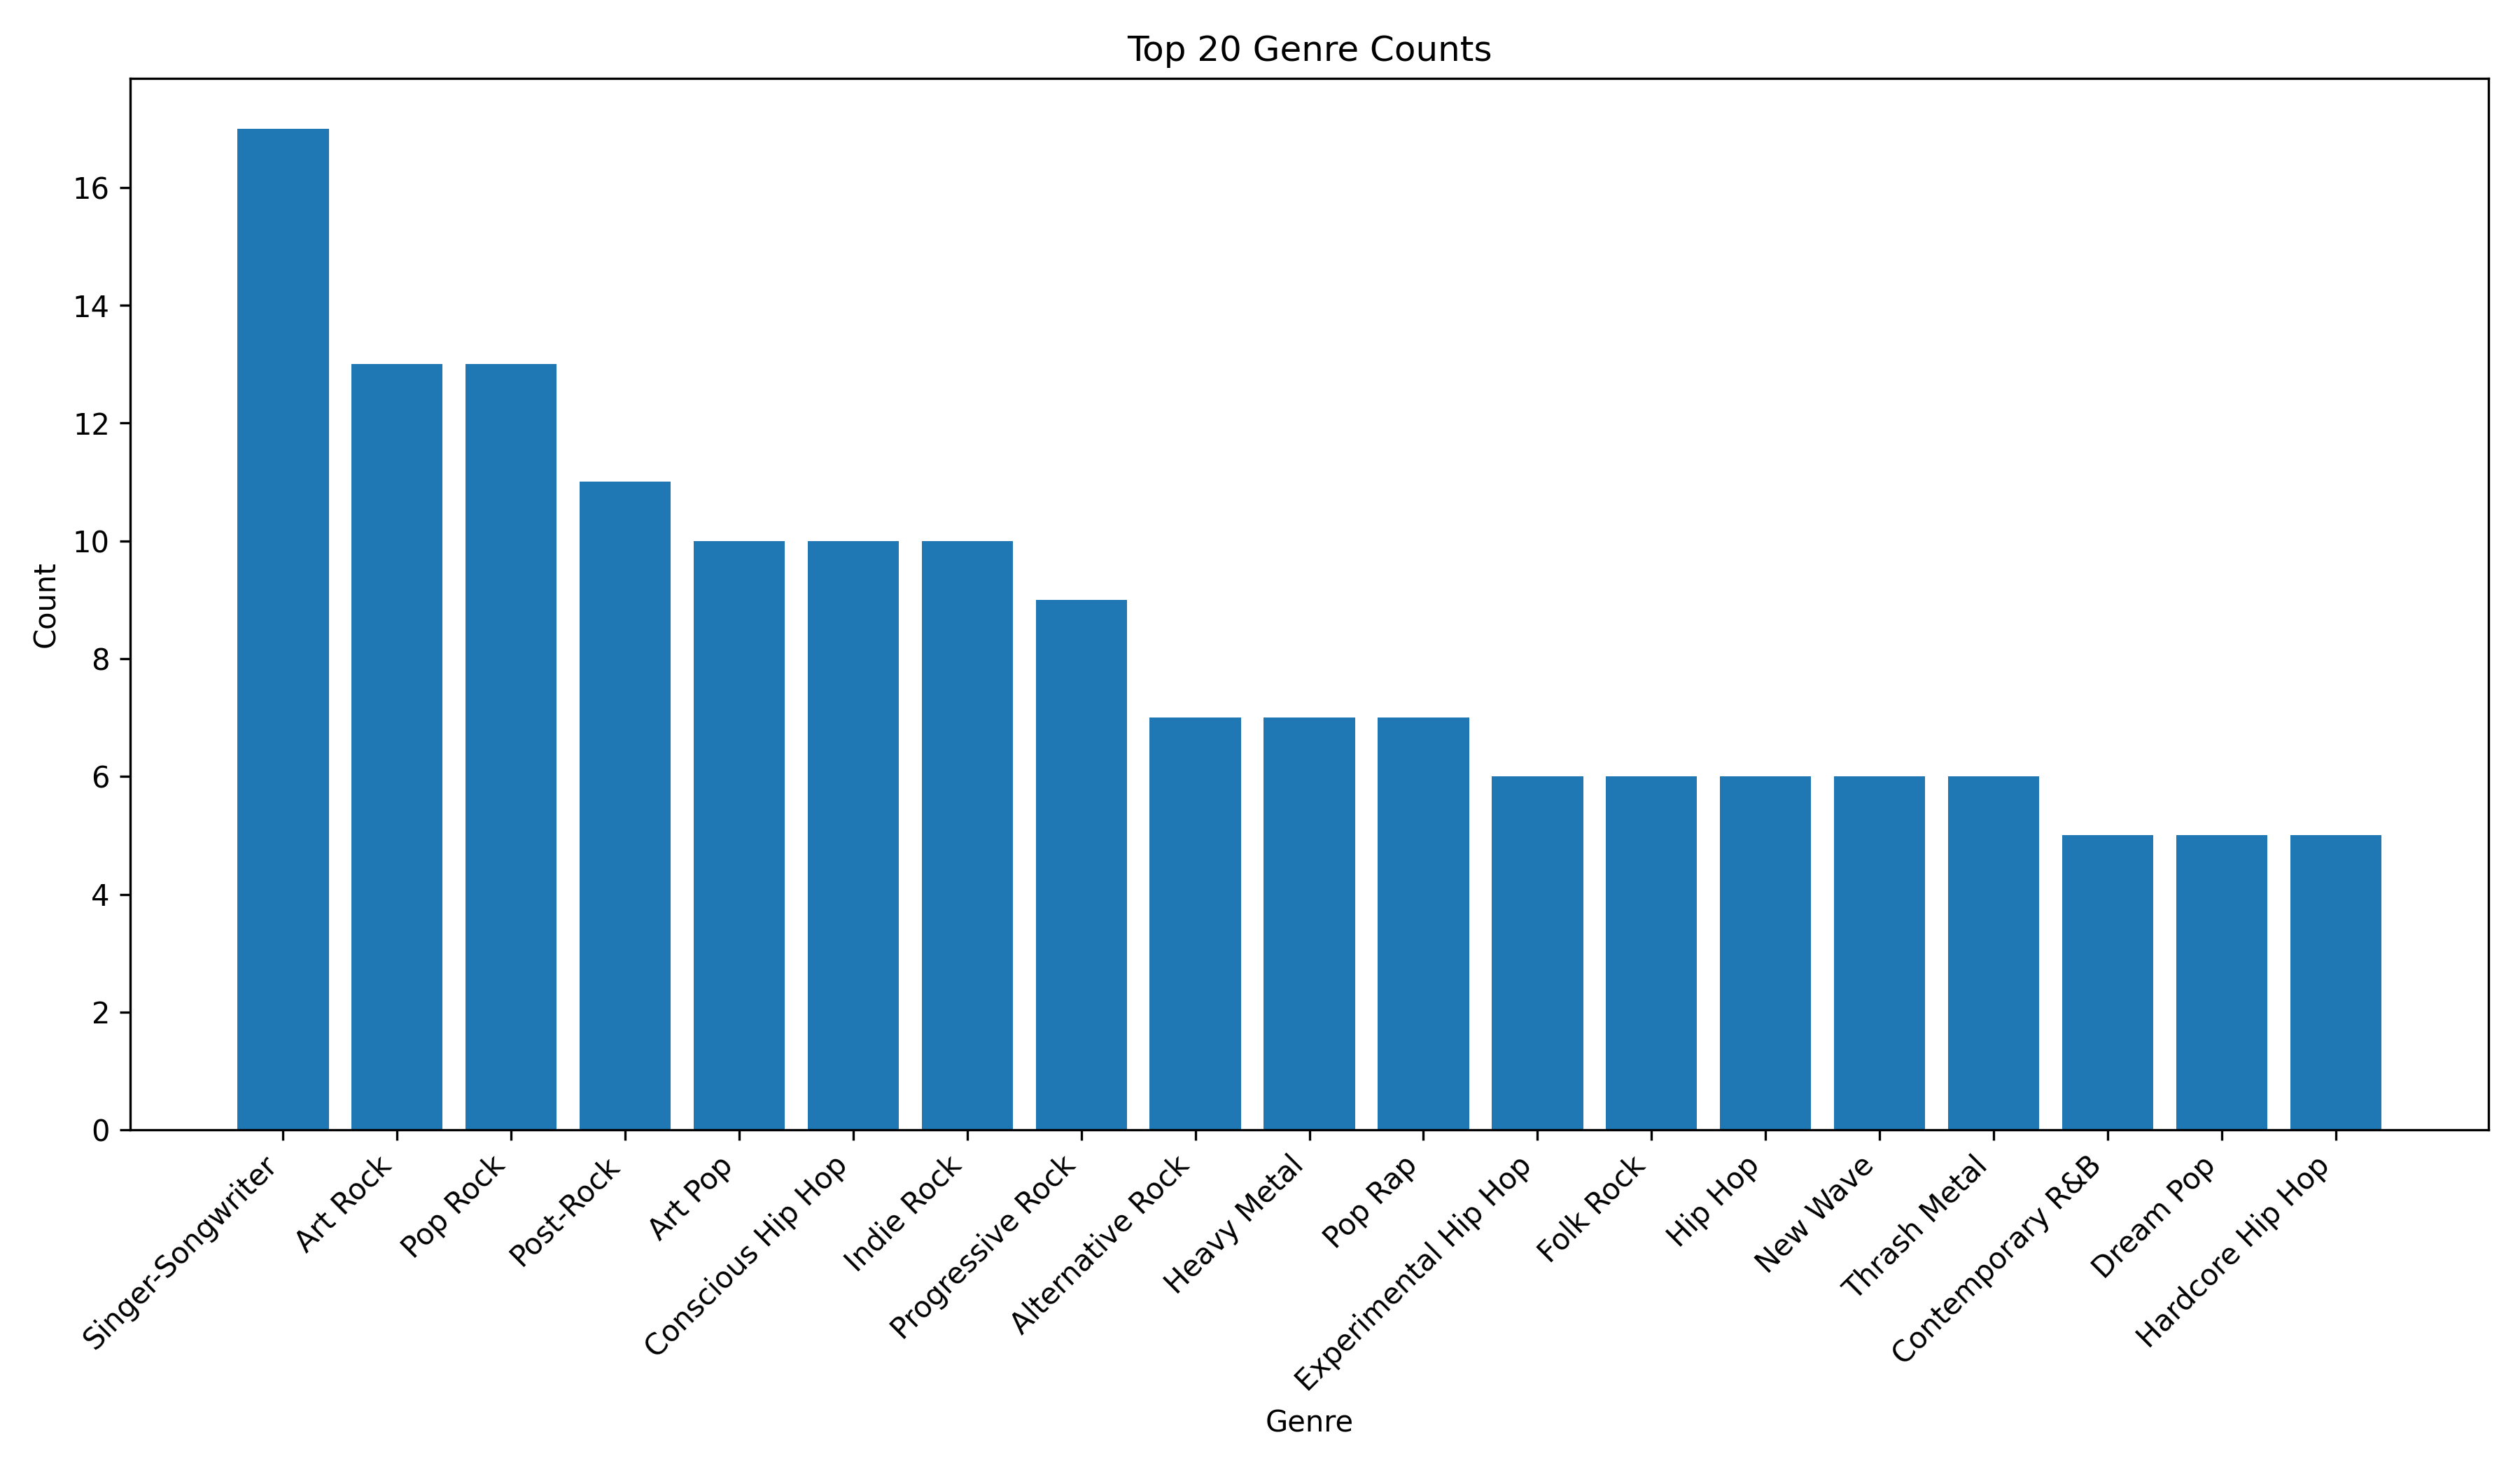

In [14]:
from IPython.display import Image
Image("top_genres_distribution.png")

## Genre Distribution

This figure shows how many albums belong to each of the most common genres after filtering. It helps identify class imbalance in the dataset. Genres with more samples are generally easier for the model to learn, while genres with fewer samples may produce less reliable results.

## Feature Construction

We convert the descriptor text into numerical features using CountVectorizer. Each descriptor becomes a binary feature indicating whether that word appears in a given album row.

In [16]:
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(df_filtered["Genre"])

X, vectorizer = build_feature_matrix(df_filtered)

print("Feature matrix shape:", X.shape)
print("Number of classes:", len(label_encoder.classes_))

Feature matrix shape: (159, 140)
Number of classes: 19


In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)

Training set shape: (127, 140)
Test set shape: (32, 140)


## Model Training

We compare three supervised learning models:
- Logistic Regression
- Decision Tree
- k-Nearest Neighbors

We use GridSearchCV with cross-validation to tune their hyperparameters.

In [19]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

In [20]:
print("Training Logistic Regression...")

log_reg_grid = {
    "C": [0.1, 1, 10],
    "solver": ["lbfgs"],
    "max_iter": [1000],
}

log_reg_search = GridSearchCV(
    LogisticRegression(random_state=RANDOM_STATE),
    log_reg_grid,
    cv=cv,
    scoring="accuracy",
    n_jobs=1,
    verbose=1,
)

log_reg_search.fit(X_train, y_train)
best_log_reg = log_reg_search.best_estimator_

print("Best Logistic Regression params:", log_reg_search.best_params_)

Training Logistic Regression...
Fitting 5 folds for each of 3 candidates, totalling 15 fits
Best Logistic Regression params: {'C': 10, 'max_iter': 1000, 'solver': 'lbfgs'}


In [21]:
print("Training k-NN...")

knn_grid = {
    "n_neighbors": [3, 5, 7, 9],
    "weights": ["uniform", "distance"],
    "metric": ["minkowski"],
}

knn_search = GridSearchCV(
    KNeighborsClassifier(),
    knn_grid,
    cv=cv,
    scoring="accuracy",
    n_jobs=1,
    verbose=1,
)

knn_search.fit(X_train, y_train)
best_knn = knn_search.best_estimator_

print("Best k-NN params:", knn_search.best_params_)

Training k-NN...
Fitting 5 folds for each of 8 candidates, totalling 40 fits
Best k-NN params: {'metric': 'minkowski', 'n_neighbors': 3, 'weights': 'distance'}


## Model Evaluation

We evaluate the models using accuracy, precision, recall, and F1-score. Since this is a classification task, these metrics indicate how well descriptor information predicts genre labels.

In [27]:
print("Training Decision Tree...")

tree_grid = {
    "max_depth": [10, 20, 40, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
}

tree_search = GridSearchCV(
    DecisionTreeClassifier(random_state=RANDOM_STATE),
    tree_grid,
    cv=cv,
    scoring="accuracy",
    n_jobs=1,
    verbose=1,
)

tree_search.fit(X_train, y_train)
best_tree = tree_search.best_estimator_

print("Best Decision Tree params:", tree_search.best_params_)

Training Decision Tree...
Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best Decision Tree params: {'max_depth': 20, 'min_samples_leaf': 2, 'min_samples_split': 5}


In [28]:
results = []

model_objects = {}

if "best_log_reg" in globals():
    model_objects["Logistic Regression"] = best_log_reg

if "best_tree" in globals():
    model_objects["Decision Tree"] = best_tree

if "best_knn" in globals():
    model_objects["k-NN"] = best_knn

for name, model in model_objects.items():
    result = evaluate_model(name, model, X_test, y_test, label_encoder)
    results.append({
        "Model": result["Model"],
        "Accuracy": result["Accuracy"],
        "Precision": result["Precision"],
        "Recall": result["Recall"],
        "F1": result["F1"],
    })

results_df = pd.DataFrame(results).sort_values("Accuracy", ascending=False)
results_df


=== Logistic Regression ===
Accuracy:  0.5000
Precision: 0.4297
Recall:    0.5000
F1-score:  0.4518

Classification Report:
                      precision    recall  f1-score   support

    Alternative Rock       0.33      1.00      0.50         1
             Art Pop       0.00      0.00      0.00         2
            Art Rock       0.25      0.33      0.29         3
   Conscious Hip Hop       0.67      1.00      0.80         2
    Contemporary R&B       0.00      0.00      0.00         1
           Dream Pop       0.00      0.00      0.00         1
Experimental Hip Hop       0.33      1.00      0.50         1
           Folk Rock       1.00      1.00      1.00         1
    Hardcore Hip Hop       0.00      0.00      0.00         1
         Heavy Metal       1.00      1.00      1.00         1
             Hip Hop       0.00      0.00      0.00         1
          Indie Rock       0.00      0.00      0.00         2
            New Wave       0.00      0.00      0.00         1
      

,Model,Accuracy,Precision,Recall,F1
0,Logistic Regression,0.50000,0.429688,0.50000,0.451786
2,k-NN,0.46875,0.448958,0.46875,0.438393
1,Decision Tree,0.40625,0.515625,0.40625,0.428125


In [29]:
results_df.to_csv("genre_model_results.csv", index=False)
results_df

,Model,Accuracy,Precision,Recall,F1
0,Logistic Regression,0.50000,0.429688,0.50000,0.451786
2,k-NN,0.46875,0.448958,0.46875,0.438393
1,Decision Tree,0.40625,0.515625,0.40625,0.428125


## Model Comparison

The table above compares the performance of the three models. Accuracy represents the proportion of correct predictions, while precision, recall, and F1-score provide additional insight into classification performance across all genres.

The model with the highest accuracy is considered the best-performing model.

In [30]:
best_model_name = results_df.iloc[0]["Model"]
best_model = model_objects[best_model_name]

print("Best model:", best_model_name)

Best model: Logistic Regression


In [31]:
best_preds = best_model.predict(X_test)

In [32]:
save_confusion_matrix(
    y_test,
    best_preds,
    label_encoder,
    "best_genre_model_confusion_matrix.png",
    top_n=TOP_N_GENRES_IN_CM,
)

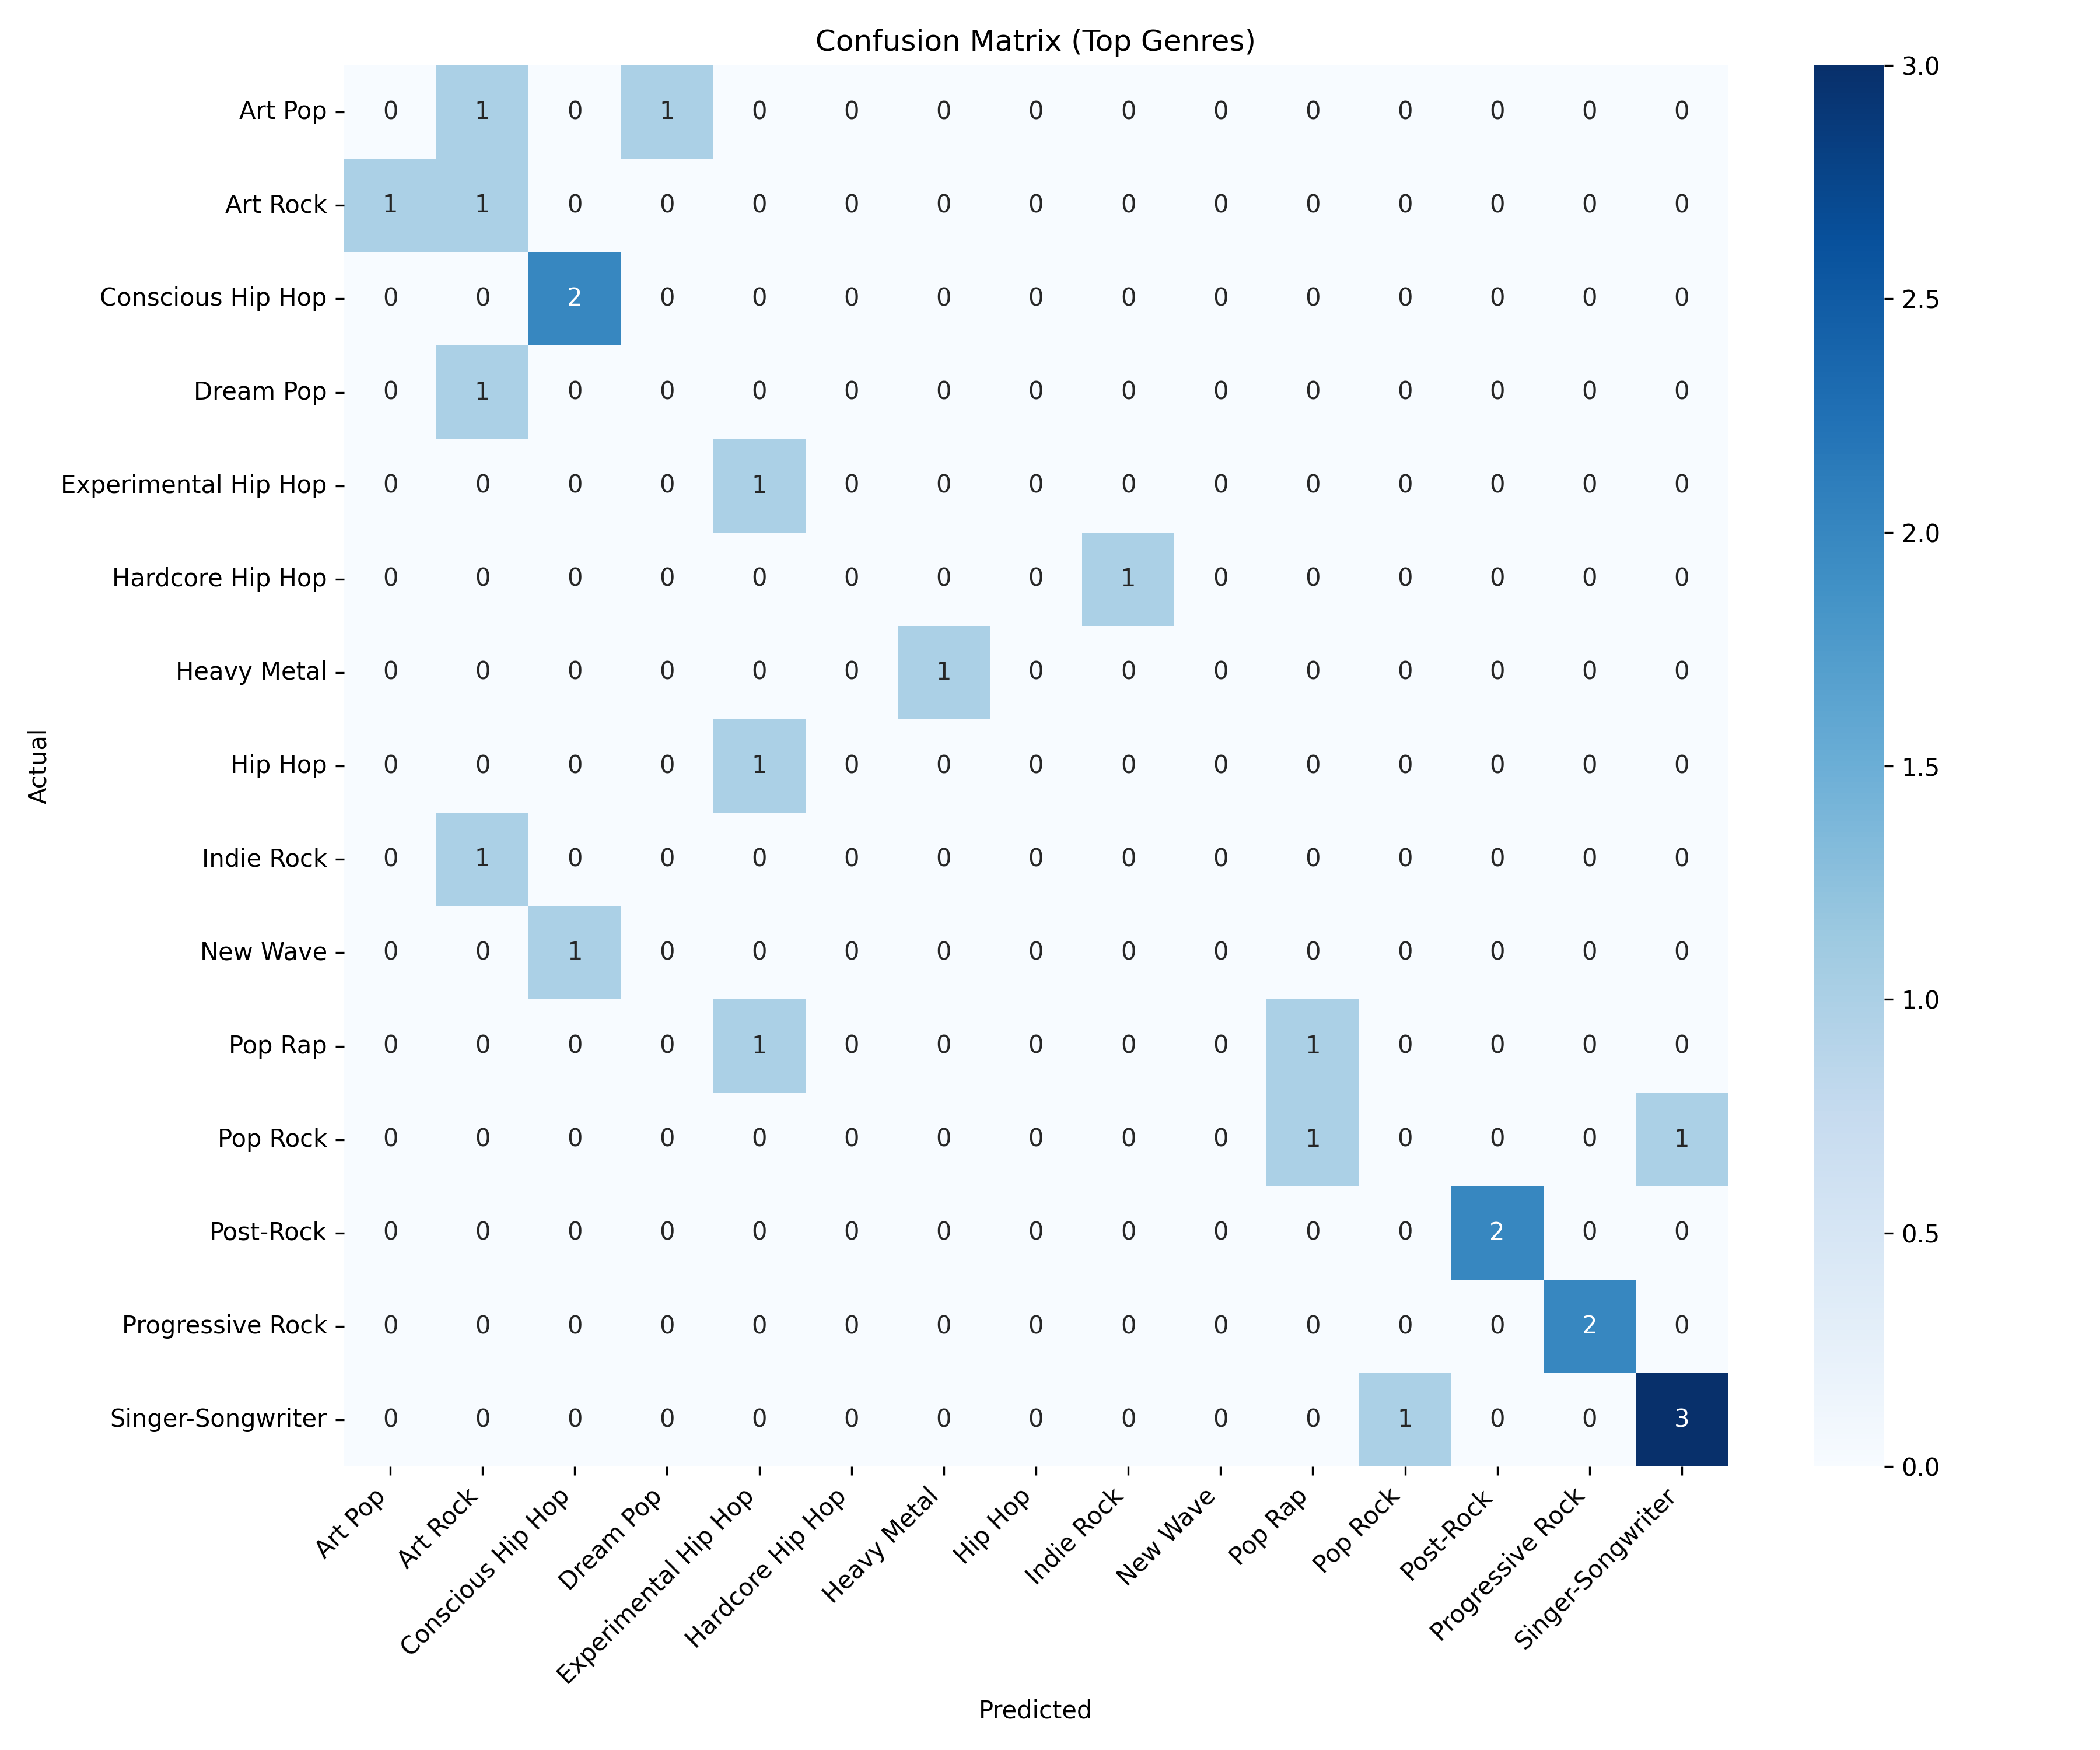

In [33]:
from IPython.display import Image
Image("best_genre_model_confusion_matrix.png")

In [34]:
save_logistic_descriptor_importance(
    best_log_reg,
    vectorizer,
    "genre_descriptor_importance.csv",
    top_n=TOP_N_DESCRIPTOR_IMPORTANCE,
)

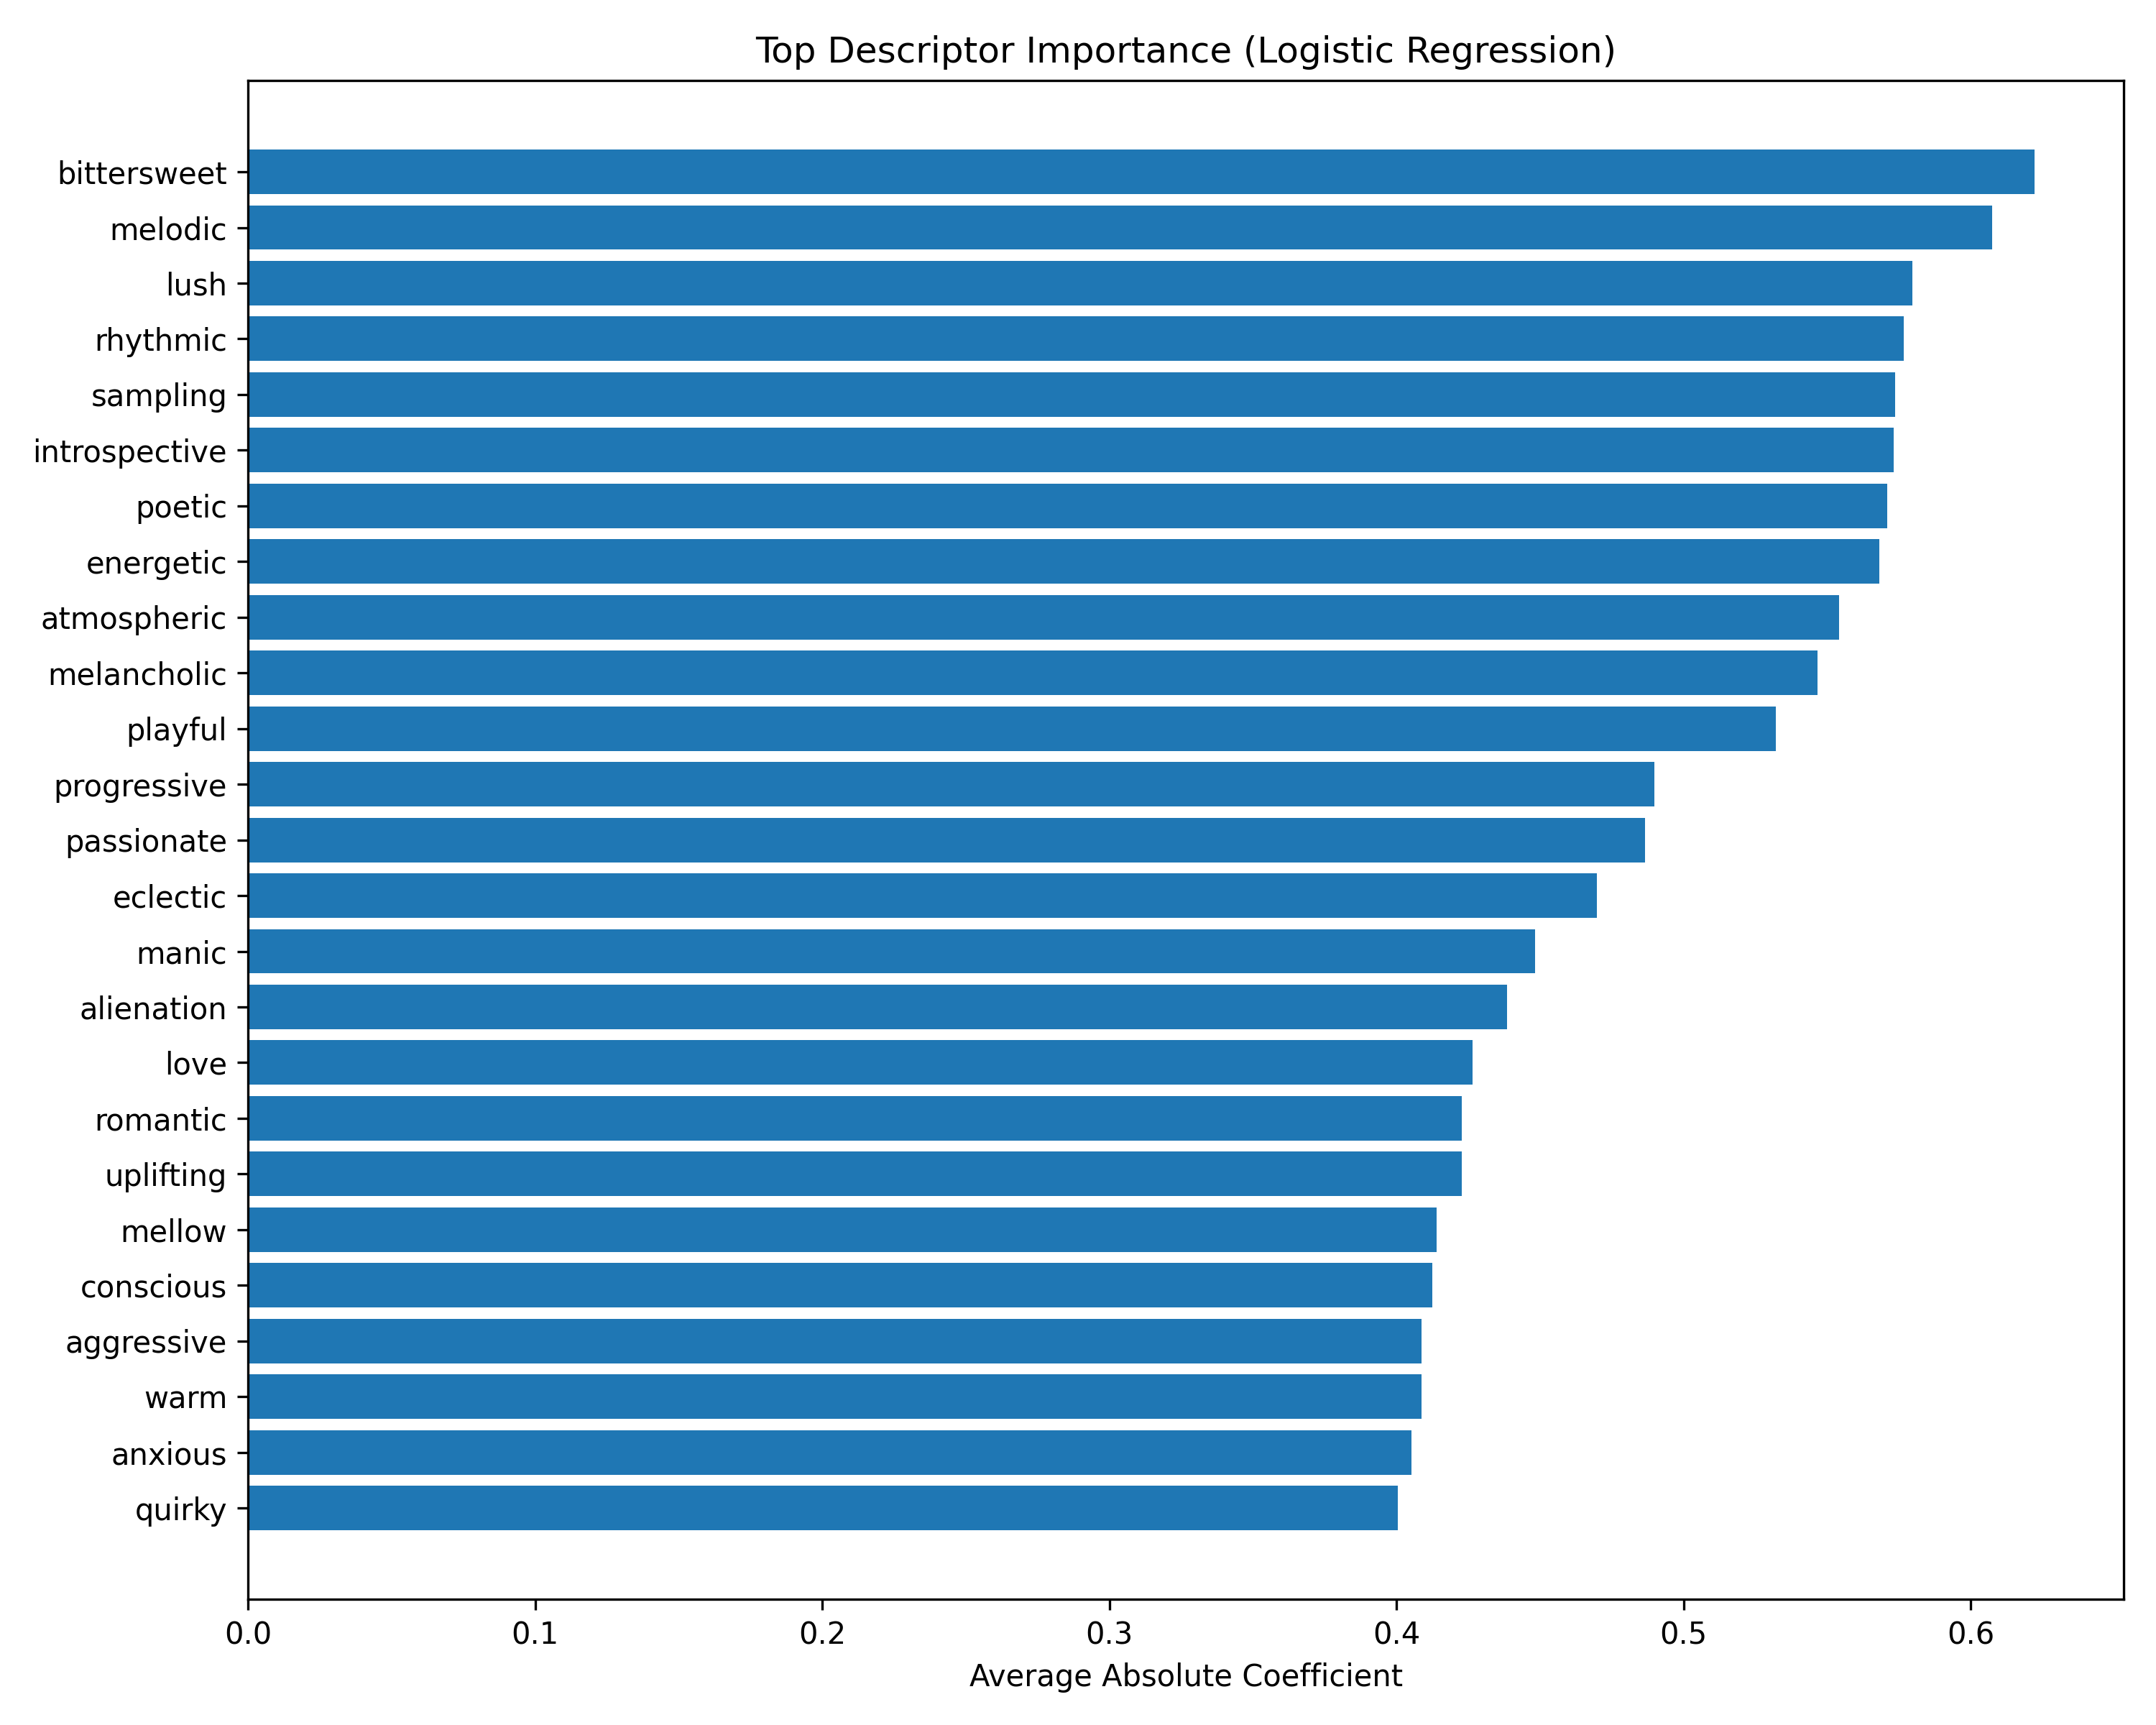

In [35]:
Image("top_descriptor_importance.png")

In [36]:
importance_df = pd.read_csv("genre_descriptor_importance.csv")
importance_df.head(20)

,Descriptor,Importance
0,bittersweet,0.622193
1,melodic,0.607472
2,lush,0.579800
3,rhythmic,0.576637
4,sampling,0.573687
5,introspective,0.573113
6,poetic,0.570863
7,energetic,0.568250
8,atmospheric,0.554279
9,melancholic,0.546676


## Descriptor Importance

The table and plot above show the most influential descriptor terms based on logistic regression coefficients.

Descriptors with higher importance values contribute more strongly to genre classification, indicating which words are most predictive of specific genres.

## Conclusion

The results show that album descriptors provide a moderate level of predictive power for genre classification. The best-performing model achieved an accuracy of approximately 50%.

However, performance is limited by class imbalance and the small number of samples per genre. Some genres are predicted very accurately, while others are frequently misclassified due to overlapping descriptor patterns.

Overall, this project demonstrates that textual descriptors can be used to predict genre, but additional data or broader genre grouping would likely improve performance.